### Hyperparameterparameter Optimization for Machine Learning

This notebook provides code to perform hyperparameter optimization (also known as hyperparameter tuning) using the Scikit-Learn package and Grid Search searching algorithm.<br>

The machine learning post-processing correction model tuned in this notebook is designed to improve retrospective streamflow simulations from the National Water Model (NWM) Version 3.0 using LightGBM. As a test case, the tuning process is demonstrated at the Otter Creek at Middlebury, VT site, which has the following characteristics:<br>
* USGS site number: 04282500
* NHDPlus comid: 22220605
* Drainage area: 1,626.51 km2
* Training and hyperparameter tuning period: up to 2018-01-01 00:00:00
* Testing period: after 2018-01-01 00:00:00 

The 44-year retrospective simulation from NWM v3.0 (February 1979 – January 2023) is publicly available at: https://registry.opendata.aws/nwm-archive/

In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

# Libraries to apply LightGBM
import lightgbm
from lightgbm import LGBMRegressor
from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
set_config(transform_output="pandas") 

# Libraries for hyperparameter tunning
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import (
    GridSearchCV,
)


In [ ]:
# Reading input dataset
dataPath = '../../input-data/hyperparameter-tuning/'
Path = "../../output-data/hyperparameter-tuning/"

# Load data:
input_features = pd.read_parquet(f'{dataPath}ml_db_wWL.parquet', engine='pyarrow') 

In [5]:
#---------------------------------
# Select the siteID to work with
#---------------------------------
input_features['siteID'].unique()
site = '04282500'
df_ml = input_features.loc[input_features['siteID'] == site]

df_ml['siteID'].unique()

#----------------------------------
# Filter dataset if needed
#----------------------------------
# Features to drop
to_drop = ["q_nwm_lag_3H",'nwm_precip_window_8_sum','nwm_precip_window_23_sum']
df_ml = df_ml.drop(columns=to_drop)
            
# Double check column names or features
print('Input variables:')
print(list(df_ml.columns.values))
# Sanity check: data span.
print('Data span:')
print(df_ml.index.min(), df_ml.index.max())

# Create a directory to save the results if it doesn't exist already
savePath = f'{Path}{site}/scikitlearn'
if not os.path.exists(savePath):
    os.makedirs(savePath)

Input variables:
['siteID', 'q_nwm', 'q_obs', 'nwm_precip', 'nwm_precip_window_8_mean', 'nwm_precip_window_23_mean', 'q_nwm_window_4_mean', 'q_nwm_window_8_mean', 'q_nwm_window_24_mean', 'q_nwm_lag_1H', 'Pobs_lag_24', 'snowDepth_lag_24', 'tmax_lag_24', 'tmin_lag_24', 'tmin_c', 'Basin_area', 'TOT_STREAM_SLOPE', 'TOT_STREAM_LENGTH', 'month', 'day', 'wl_obs_lag_4H', 'wl_obs_lag_6H', 'wl_obs_lag_8H']
Data span:
1979-02-01 00:00:00 2023-02-01 00:00:00


In [6]:
#-----------------------------------------
# PREPARE ML MODEL
#-----------------------------------------
# Define our target value
target = ["q_obs"]

# Rescale our features and put into a pipeline. 
# This pipeline could be extended to include the creation of new features
pipeline = make_pipeline(MinMaxScaler())

# Let's see the pipeline to double-check
#pipeline

# Let's check how our feature engineering pipeline behaves
#pipeline.fit_transform(df_ml)
# We can use `clone` to return an unfitted version
# of the pipeline.
#pipeline = clone(pipeline)

#----------------------------
# --- CONFIG --- #
# Define time of first prediction, this determines our train / test split
forecast_start_time = pd.to_datetime("2018-01-01 00:00:00")
        
# --- CREATE TRAINING & TESTING DATAFRAME  --- #
# Ensure we only have training data up to the start
# of the forecast.
df_train = df_ml.loc[df_ml.index < forecast_start_time].copy()
df_train = df_train.drop(columns=['siteID'])
df_train_bckup = df_ml.loc[df_ml.index < forecast_start_time].copy()

df_test = df_ml.loc[df_ml.index >= forecast_start_time].copy()
df_test = df_test.drop(columns=['siteID'])
df_test_bckup = df_ml.loc[df_ml.index >= forecast_start_time].copy()

# Create X_train and y_train
X_train = pipeline.fit_transform(df_train.dropna()).drop(columns=["q_obs"])
y_train = df_train.dropna()[target]

X_test = pipeline.transform(df_test.dropna()).drop(columns=["q_obs"])
y_test = df_test.dropna()[target]

In [ ]:
#----------------------------------------    
# --- HYPERPARAMETER OPTIMIZATION --- #
#----------------------------------------
Identifier = 'sklern_GS'

# Define the model.
model = LGBMRegressor(
                      boosting = "gbdt",
                      linear_tree=True, 
                      linear_lambda=0.1, 
                      #n_estimators=300,
                      importance_type='split',
                     )

# Determine the hyperparameter space
param_grid = dict(
    n_estimators = [100, 150,200,250,300,500, 1000],
    num_leaves=[10, 20, 30, 40, 100, 120],
    min_data_in_leaf=[1, 10, 20,150,200],
    max_depth=[1, 3, 4, 6, 5, 10],
    ) 

# Define the method to perform cross-validation split for time series
cv_split = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)

# Set up the search
search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_root_mean_squared_error', cv=cv_split, refit=True)

# Find best hyperparameters
search.fit(X_train, y_train)

# The best hyperparameters are stored in an attribute
print(search.best_params_)

# We also find the data for all models evaluated
results = pd.DataFrame(search.cv_results_)
print(results.shape)

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current v

In [30]:
#----- Explore the results ------#
# we can order the different models based on their performance
results.sort_values(by='mean_test_score', ascending=False, inplace=True)
results.reset_index(drop=True, inplace=True)
print(results[[
    'param_num_leaves', 'param_min_data_in_leaf', 'param_max_depth','param_n_estimators',
]].head())

# plot model performance and error
#figure = plt.gcf()
#figure.set_size_inches(7, 4)
#results['mean_test_score'].plot(yerr=[results['std_test_score'], results['std_test_score']], subplots=True)
#plt.ylabel('Mean test score')
#plt.xlabel('Hyperparameter combinations')
#plt.savefig(savePath+"/"+'Hyperparameter combinations_skitlearn_'+site+'.png',dpi=(100), bbox_inches='tight')

X_train_preds = search.predict(X_train)
X_test_preds = search.predict(X_test)

print('Train accuracy: ', root_mean_squared_error(y_train, X_train_preds))
print('Test accuracy: ', root_mean_squared_error(y_test, X_test_preds))

# let's make a function to evaluate the model performance based on
# single hyperparameters
def summarize_by_param(hparam):
    tmp = pd.concat([
        results.groupby(hparam)['mean_test_score'].mean(),
        results.groupby(hparam)['mean_test_score'].std(),
    ], axis=1)

    tmp.columns = ['mean_test_score', 'std_test_score']
    
    return tmp

  param_num_leaves param_min_data_in_leaf param_max_depth param_n_estimators
0               40                    200               3                300
1               10                    200               3                300
2              120                    200               3                300
3              100                    200               3                300
4               30                    200               3                300
Train accuracy:  0.9941496727375398
Test accuracy:  23.155875728668555


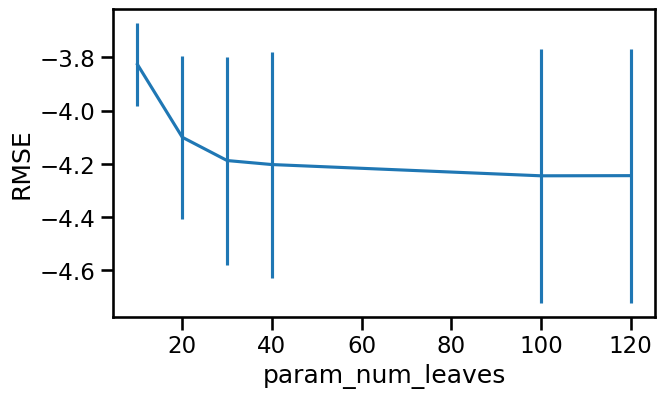

In [ ]:
# Performance change for n_estimators
figure = plt.gcf()
figure.set_size_inches(7, 4)
tmp = summarize_by_param('param_num_leaves')
tmp['mean_test_score'].plot(yerr=[tmp['std_test_score'], tmp['std_test_score']], subplots=True)
plt.ylabel('RMSE')
plt.savefig(savePath+"/"+'param_num_leaves_sklearn_'+site+'.png',dpi=(100), bbox_inches='tight')

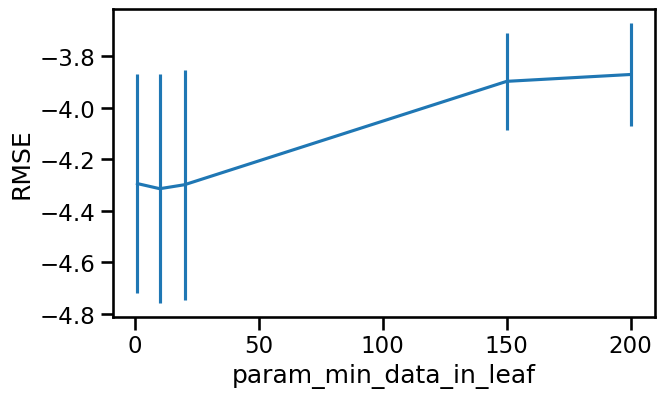

In [31]:
figure = plt.gcf()
figure.set_size_inches(7, 4)
tmp = summarize_by_param('param_num_leaves')
tmp = summarize_by_param('param_min_data_in_leaf')
tmp['mean_test_score'].plot(yerr=[tmp['std_test_score'], tmp['std_test_score']], subplots=True)
plt.ylabel('RMSE')
plt.savefig(savePath+"/"+'param_min_data_in_leaf_sklearn_'+site+'.png',dpi=(100), bbox_inches='tight')

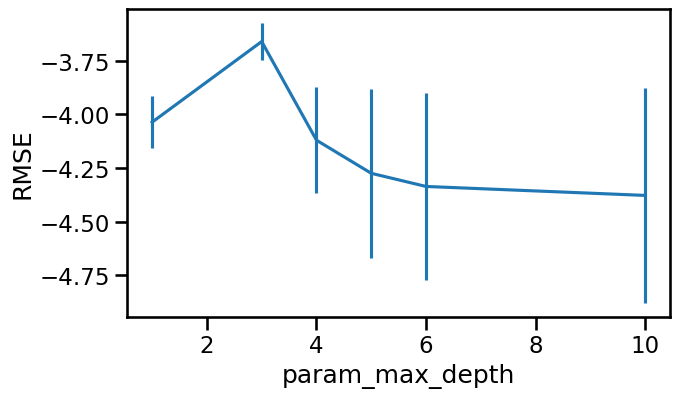

In [32]:
figure = plt.gcf()
figure.set_size_inches(7, 4)
tmp = summarize_by_param('param_max_depth')
tmp['mean_test_score'].plot(yerr=[tmp['std_test_score'], tmp['std_test_score']], subplots=True)
plt.ylabel('RMSE')
plt.savefig(savePath+"/"+'param_max_depth_sklearn_'+site+'.png',dpi=(100), bbox_inches='tight')

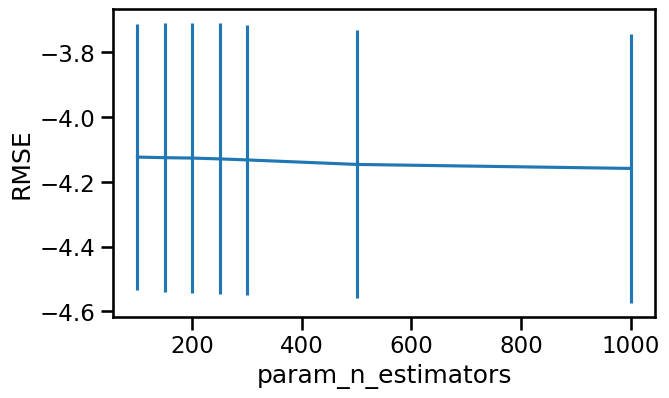

In [33]:
figure = plt.gcf()
figure.set_size_inches(7, 4)
tmp = summarize_by_param('param_n_estimators')
tmp['mean_test_score'].plot(yerr=[tmp['std_test_score'], tmp['std_test_score']], subplots=True)
plt.ylabel('RMSE')
plt.savefig(savePath+"/"+'param_n_estimators_sklearn_'+site+'.png',dpi=(100), bbox_inches='tight')